In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
data_path = '../../data/1minute_data_austin/1minute_data_austin.csv'
data_raw = pd.read_csv(data_path)
data_raw['localminute'] = pd.to_datetime(data_raw['localminute'], utc=True)

In [33]:
columns = data_raw.columns
home_ids = data_raw["dataid"].unique()
num_rows = data_raw["dataid"].value_counts()

In [115]:
coverage = (
    data_raw.groupby('dataid')['localminute']
    .agg(min_ts='min', max_ts='max', actual_entries='count')
    .assign(
        time_span=lambda d: d['max_ts'] - d['min_ts'] + pd.Timedelta(minutes=1),
        time_span_minutes=lambda d: d['time_span'].dt.total_seconds() / 60,
        coverage_ratio=lambda d: d['actual_entries'] / (d['time_span'].dt.total_seconds() / 60),
    )
)
coverage

,min_ts,max_ts,actual_entries,time_span,time_span_minutes,coverage_ratio
dataid,,,,,,
661,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525530,365 days 00:00:00,525600.0,0.999867
1642,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,519780,365 days 00:00:00,525600.0,0.988927
2335,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,517080,365 days 00:00:00,525600.0,0.983790
2361,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,524820,365 days 00:00:00,525600.0,0.998516
2818,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,524760,365 days 00:00:00,525600.0,0.998402
3039,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525596,365 days 00:00:00,525600.0,0.999992
3456,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,524040,365 days 00:00:00,525600.0,0.997032
3538,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525600,365 days 00:00:00,525600.0,1.000000
4031,2018-01-01 06:00:00+00:00,2019-01-01 05:59:00+00:00,525600,365 days 00:00:00,525600.0,1.000000


In [154]:
feature_cols = [c for c in data_raw.columns if c not in ('dataid', 'localminute')]
fill_pct = (
    data_raw.groupby('dataid')[feature_cols]
    .apply(lambda g: g.notna().mean() * 100)
)
fill_pct

,air1,air2,air3,airwindowunit1,aquarium1,bathroom1,bathroom2,bedroom1,bedroom2,bedroom3,...,sprinkler1,sumppump1,utilityroom1,venthood1,waterheater1,waterheater2,wellpump1,winecooler1,leg1v,leg2v
dataid,,,,,,,,,,,,,,,,,,,,,
661,99.052385,0.000000,0.0,0.0,0.0,91.531216,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,98.972466,98.972466
1642,99.480549,0.000000,0.0,0.0,0.0,96.616838,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,96.616838,96.616838,0.000000,0.000000,0.0,0.000000,99.388203,99.388203
2335,99.996519,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,99.988396,0.000000,0.000000,0.0,0.000000,99.915294,99.915294
2361,100.000000,0.000000,0.0,0.0,0.0,100.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,100.000000,0.000000,0.000000,0.0,0.000000,99.908540,99.908540
2818,100.000000,0.000000,0.0,0.0,0.0,99.908530,0.000000,99.908530,0.000000,0.000000,...,100.0,0.0,0.000000,100.000000,0.000000,0.000000,0.0,0.000000,99.908530,99.908530
3039,98.504555,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,91.872084,91.872084,0.0,91.872084,98.436822,98.436822
3456,99.988550,0.000000,0.0,0.0,0.0,100.000000,0.000000,100.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,99.896954,99.896954
3538,100.000000,0.000000,0.0,0.0,0.0,99.908676,0.000000,99.988584,0.000000,0.000000,...,100.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,99.920091,99.920091
4031,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,99.920091,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,99.908676,99.908676


In [164]:
fill_pct.mean().sort_values()[::-1]

grid             99.404082
leg2v            99.326231
leg1v            99.326231
dishwasher1      98.627198
air1             95.400884
                   ...    
heater3           0.000000
housefan1         0.000000
icemaker1         0.000000
lights_plugs5     0.000000
jacuzzi1          0.000000
Length: 77, dtype: float64

In [136]:
def get_single_home(homeid): 
    df_home = data_raw.loc[data_raw["dataid"] == homeid]
    df_home = df_home.drop(columns = ["dataid", "leg1v", "leg2v"])
    df_home = df_home.dropna(axis=1, how="all")
    df_home = df_home.set_index("localminute")
    df_home.index = pd.to_datetime(df_home.index, utc = True)
    return df_home

In [147]:
df_home = get_single_home(9922)
df_home_hourly = df_home.resample("H").mean()

/var/folders/0h/cpmzljqs7y98z5g9zx33_kmc0000gn/T/ipykernel_9066/2852525784.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_home_hourly = df_home.resample("H").mean()


<Axes: xlabel='localminute'>

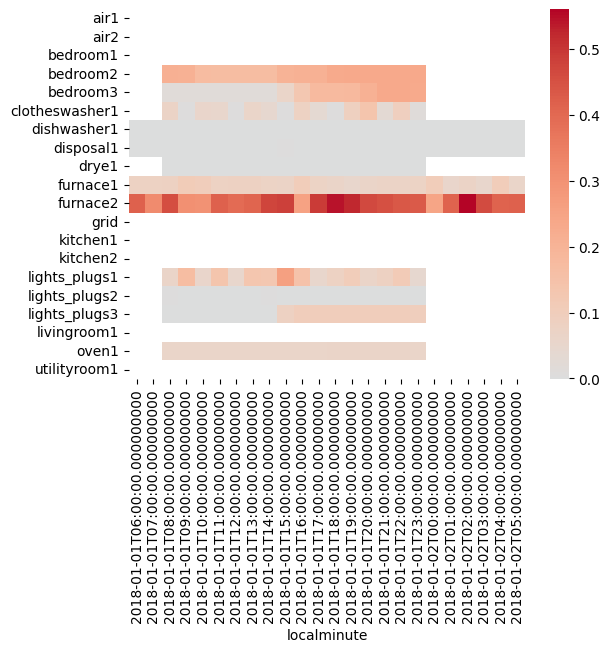

In [172]:
sns.heatmap(data = df_home_hourly.T.iloc[:, :24], cmap = "coolwarm", center = 0)

<Axes: xlabel='localminute'>

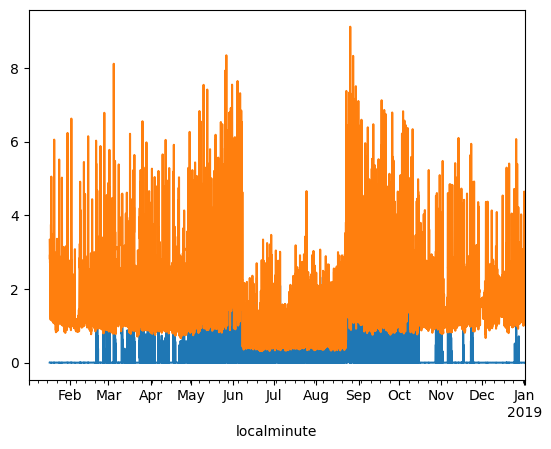

In [177]:
df_home_hourly['air1'].plot()
df_home_hourly['grid'].plot()